# Análisis Comparativo: Ensambles, SVM y Redes Neuronales
## Modelos Avanzados de Clasificación de Escolaridad - EMAT 2024

---

**Curso:** SC3314 – Inteligencia Artificial  
**Estudiante:** Ricardo Arath Sanchez Aguirre  
**Profesor:** Dr. Antonio Martínez Torteya  
**Fecha:** Marzo 19, 2026  
**Actividad:** A2.3 - Modelos de Ensamble, SVM y Redes Neuronales

## 1. Introducción

### 1.1 Contexto del Estudio

Tras explorar modelos lineales (LDA) y basados en particiones (Árboles de Decisión) en análisis previos, este reporte aborda la pregunta: **¿Cómo cambia el desempeño y el comportamiento cuando utilizamos modelos más complejos y flexibles?**

El presente análisis utiliza datos del Estatal de Matrimonios (EMAT) 2024 de México, que contiene **486,645 registros** de matrimonios celebrados durante el año. Este dataset captura información demográfica fundamental para estudiar metodologías de clasificación supervisada en un contexto real y de gran escala.

### 1.2 Pregunta de Investigación

¿Cómo se comparan cuatro metodologías avanzadas de clasificación—**Random Forest, Gradient Boosting, Support Vector Machine y una Red Neuronal Simple**—en su capacidad de predecir la categoría de escolaridad del primer contrayente, dados predictores demográficos limitados?

### 1.3 Variable Objetivo y Predictores

**Variable Objetivo:** Escolaridad del primer contrayente (`escol_con1`) - 3 clases más frecuentes del dataset

**Predictores:** edad_con1, edad_con2, anio_regis, sexo_con1, naci_con1 (mismos que en análisis previos para garantizar comparabilidad)

### 1.4 Objetivos Específicos

1. **Entrenar y evaluar cuatro modelos distintos:** Random Forest (ensamble), Gradient Boosting (ensamble), SVM (margen máximo) y Red Neuronal (redes profundas simples)

2. **Comparar desempeño cuantitativamente:** Usando métricas estándar (Accuracy, Precision, Recall, F1-Score) en datos de prueba no vistos

3. **Analizar la relación complejidad-desempeño:** ¿Se justifica la mayor complejidad de estos modelos con mejoras substanciales?

4. **Evaluar riesgos de sobreajuste:** Comparar desempeño en entrenamiento vs prueba

5. **Reflexionar sobre interpretabilidad relativa:** Por qué algunos modelos son más explicables que otros

6. **Formular recomendaciones contextuales:** Cuándo preferir uno sobre otro según el escenario de uso

## 2. Metodología

### 2.1 Preparación de los Datos

Se utiliza el **mismo conjunto de datos y partición** que en análisis previos para garantizar comparabilidad:

- **Dataset:** EMAT 2024 con 100,000 muestras estratificadas
- **Clases:** Las 3 categorías de escolaridad más frecuentes
- **Partición:** Estratificada 70-30 (70,000 entrenamiento, 30,000 prueba)
- **Predictores:** 5 variables (3 numéricas + 2 categóricas codificadas)

**Procesamiento:** Variables categóricas codificadas con LabelEncoder; valores faltantes imputados con la media; sin normalización para permitir comparabilidad con métodos anteriores.

### 2.2 Descripción de Modelos y Justificación de Hiperparámetros

#### 2.2.1 Random Forest (Ensamble)

**Fundamento:** Ensamble de B árboles de decisión entrenados con bootstrap (muestreo con reemplazo). Cada árbol se entrena en una muestra aleatoria, y las predicciones finales se promedian (regresión) o votan por mayoría (clasificación).

**Ventajas sobre un árbol único:**
- Reduce varianza del modelo mediante agregación
- Mantiene introducción de nuevas características en cada división (feature importance global)
- Robusto a outliers y ruido

**Hiperparámetros seleccionados:**
- `n_estimators=150`: 150 árboles. Número moderado que balancea capacidad predictiva con costo computacional
- `max_depth=15`: Profundidad moderada para mantener complejidad
- `min_samples_split=20`, `min_samples_leaf=10`: Restricciones anti-overfitting
- `random_state=42`: Reproducibilidad

#### 2.2.2 Gradient Boosting (Ensamble)

**Fundamento:** Ensamble de árboles entrenados **secuencialmente**. Cada árbol nuevo se entrena para corregir los errores de los anteriores, minimizando una función de pérdida mediante descenso de gradiente.

**Diferencia vs Random Forest:** 
- RF: Árboles independientes en paralelo (reduce varianza)
- GB: Árboles correlativos en serie (reduce sesgo y varianza iterativamente)

**Hiperparámetros seleccionados:**
- `n_estimators=150`: Etapas de boosting
- `learning_rate=0.1`: Tamaño de paso en corrección de errores. Valor conservador que permite convergencia lenta pero más estable
- `max_depth=5`: Árboles más superficiales que RF para evitar overfitting en modelo secuencial
- `random_state=42`: Reproducibilidad

#### 2.2.3 Support Vector Machine - SVM (Margen Máximo)

**Fundamento:** Encuentra un hiperplano que maximiza el margen (distancia) entre clases. Usa funciones kernel para mapear datos a dimensiones superiores donde sean más separables.

**Ventajas:**
- Muy efectivo en altas dimensiones
- Manejo automático de complejidad mediante kernel
- Matemáticamente principiista (max-margin principle)

**Desventajas:**
- Menos interpretable (decisiones implícitas)
- Sensible a escala de variables (~requeriría normalización, aquí omitida por comparabilidad)

**Hiperparámetros seleccionados:**
- `kernel='rbf'`: Radial Basis Function. Flexible para capturar relaciones no-lineales
- `C=1.0`: Parámetro de regularización (default). Balancea margen máximo vs tolerancia de error
- `random_state=42`: Reproducibilidad

#### 2.2.4 Red Neuronal Simple (Perceptrón Multicapa)

**Fundamento:** Red feedforward con capas ocultas que aprende transformaciones jerárquicas de los datos mediante backpropagation. Capacidad de aproximar funciones altamente no-lineales.

**Arquitectura seleccionada:**
```
Input (5) → Hidden1 (64) → Hidden2 (32) → Output (3)
Activation: ReLU (capas ocultas), Softmax (salida)
```

**Justificación:**
- `hidden_layer_sizes=(64, 32)`: Dos capas permitiendo aprender representaciones complejas sin complejidad excesiva
- 64 → 32 neuronas: Embudo que comprime gradualmente para regularización
- Total parámetros: ~3,400

**Hiperparámetros de entrenamiento:**
- `solver='adam'`: Optimizador adaptativo velocidad-aprendizaje (alternativa a SGD probada)
- `learning_rate_init=0.001`: Tasa de aprendizaje conservadora
- `max_iter=500`: Iteraciones suficientes para convergencia
- `random_state=42`: Reproducibilidad

### 2.3 Métricas de Evaluación

Se evalúan cuatro métricas en el conjunto de **prueba** (datos no vistos):

| Métrica | Interpretación |
|---------|----------------|
| **Accuracy** | Proporción global de predicciones correctas (0-1) |
| **Precision** | De lo predicho positivo, cuánto fue correcto (macro-promediado) |
| **Recall** | De lo realmente positivo, cuánto detectamos (macro-promediado) |
| **F1-Score** | Balance armónico entre precision y recall (macro-promediado) |

El **promediado macro** trata todas las clases con igual importancia; apropiado aquí donde las 3 clases están balanceadas.

## 3. Resultados

### 3.1 Ejecución del Análisis Completo

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    precision_score, recall_score, f1_score
)
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['OPENBLAS_NUM_THREADS'] = '1'
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

In [2]:
chunk_size = 50000
chunks = []
for i, chunk in enumerate(pd.read_csv(
    'conjunto_de_datos_emat2024_csv/conjunto_de_datos/conjunto_de_datos_emat2024.csv',
    chunksize=chunk_size
), 1):
    chunks.append(chunk)

df = pd.concat(chunks, ignore_index=True)
print(f"Dataset cargado: {df.shape[0]:,} registros, {df.shape[1]} variables")

Dataset cargado: 486,645 registros, 35 variables


In [3]:
target_col = 'escol_con1'
top_classes = df[target_col].value_counts().head(3).index.tolist()
df_filtered = df[df[target_col].isin(top_classes)].copy()

print(f"Registros con 3 clases objetivo: {len(df_filtered):,}")
print("\nDistribución de clases:")
for cls in df_filtered[target_col].value_counts().index:
    count = (df_filtered[target_col] == cls).sum()
    pct = 100 * count / len(df_filtered)
    print(f"  Clase {cls}: {count:7,} ({pct:5.1f}%)")

Registros con 3 clases objetivo: 389,762

Distribución de clases:
  Clase 6: 141,329 ( 36.3%)
  Clase 7: 132,818 ( 34.1%)
  Clase 5: 115,615 ( 29.7%)


In [4]:
max_samples = 100000
if len(df_filtered) > max_samples:
    df_filtered = df_filtered.sample(n=max_samples, random_state=42)

predictors = ['edad_con1', 'edad_con2', 'anio_regis']
categorical_features = ['sexo_con1', 'naci_con1']
all_features = predictors + categorical_features

df_model = df_filtered[all_features + [target_col]].copy()

for col in categorical_features:
    le = LabelEncoder()
    df_model[col] = df_model[col].fillna('Unknown')
    df_model[col] = le.fit_transform(df_model[col].astype(str))

X = df_model[all_features].copy()
X = X.fillna(X.mean())

le_target = LabelEncoder()
y = le_target.fit_transform(df_model[target_col].astype(str))

print(f"Matriz X: {X.shape}")
print(f"Vector y: {y.shape} con {len(np.unique(y))} clases")

Matriz X: (100000, 5)
Vector y: (100000,) con 3 clases


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Entrenamiento: {len(y_train):,} muestras")
print(f"Prueba: {len(y_test):,} muestras")
print("\nVerificación de estratificación:")
for class_idx in sorted(np.unique(y)):
    train_pct = 100 * (y_train == class_idx).sum() / len(y_train)
    test_pct = 100 * (y_test == class_idx).sum() / len(y_test)
    print(f"  Clase {class_idx}: {train_pct:5.1f}% (train) vs {test_pct:5.1f}% (test)")

Entrenamiento: 70,000 muestras
Prueba: 30,000 muestras

Verificación de estratificación:
  Clase 0:  29.6% (train) vs  29.6% (test)
  Clase 1:  36.2% (train) vs  36.2% (test)
  Clase 2:  34.2% (train) vs  34.2% (test)


In [6]:
rf = RandomForestClassifier(
    n_estimators=150, max_depth=15, min_samples_split=20,
    min_samples_leaf=10, random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
print(f"Random Forest entrenado: {rf.n_estimators} árboles, profundidad máx: {rf.max_depth}")

Random Forest entrenado: 150 árboles, profundidad máx: 15


In [7]:
gb = GradientBoostingClassifier(
    n_estimators=150, learning_rate=0.1, max_depth=5,
    random_state=42
)
gb.fit(X_train, y_train)
print(f"Gradient Boosting entrenado: {gb.n_estimators} etapas, learning_rate: {gb.learning_rate}")

Gradient Boosting entrenado: 150 etapas, learning_rate: 0.1


In [8]:
svm = SVC(kernel='rbf', C=1.0, random_state=42)
svm.fit(X_train, y_train)
print(f"SVM entrenado: kernel=rbf, C=1.0, vectores soporte: {svm.n_support_}")

SVM entrenado: kernel=rbf, C=1.0, vectores soporte: [20726 24092 23912]


In [9]:
nn = MLPClassifier(
    hidden_layer_sizes=(64, 32), solver='adam', learning_rate_init=0.001,
    max_iter=500, random_state=42, early_stopping=True,
    validation_fraction=0.1, n_iter_no_change=50
)
nn.fit(X_train, y_train)
print(f"Red Neuronal entrenada: capas {nn.hidden_layer_sizes}, parámetros: {sum(p.size for p in nn.coefs_) + sum(b.size for b in nn.intercepts_)}")

Red Neuronal entrenada: capas (64, 32), parámetros: 2563


### 3.2 Resultados Cuantitativos - Desempeño en Prueba

In [10]:
y_pred_rf = rf.predict(X_test)
y_pred_gb = gb.predict(X_test)
y_pred_svm = svm.predict(X_test)
y_pred_nn = nn.predict(X_test)

models_results = {}

for model_name, y_pred in [('Random Forest', y_pred_rf), ('Gradient Boosting', y_pred_gb), 
                            ('SVM', y_pred_svm), ('Red Neuronal', y_pred_nn)]:
    models_results[model_name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='macro', zero_division=0),
        'Recall': recall_score(y_test, y_pred, average='macro', zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, average='macro', zero_division=0)
    }

results_table = pd.DataFrame(models_results).T

print("RESULTADOS EN CONJUNTO DE PRUEBA - 4 MODELOS AVANZADOS")
print(results_table.round(4))
print("\n")
print("RESUMEN ESTADÍSTICO:")
print(f"Accuracy - Máximo: {results_table['Accuracy'].max():.4f} ({results_table['Accuracy'].idxmax()})")
print(f"Accuracy - Mínimo: {results_table['Accuracy'].min():.4f} ({results_table['Accuracy'].idxmin()})")
print(f"Accuracy - Rango: {results_table['Accuracy'].max() - results_table['Accuracy'].min():.4f}")

RESULTADOS EN CONJUNTO DE PRUEBA - 4 MODELOS AVANZADOS
                   Accuracy  Precision  Recall  F1-Score
Random Forest        0.4392     0.4317  0.4312    0.4196
Gradient Boosting    0.4442     0.4368  0.4372    0.4251
SVM                  0.3628     0.2238  0.3348    0.2069
Red Neuronal         0.4342     0.4269  0.4285    0.4204


RESUMEN ESTADÍSTICO:
Accuracy - Máximo: 0.4442 (Gradient Boosting)
Accuracy - Mínimo: 0.3628 (SVM)
Accuracy - Rango: 0.0814


In [11]:
conf_matrices = {
    'Random Forest': confusion_matrix(y_test, y_pred_rf),
    'Gradient Boosting': confusion_matrix(y_test, y_pred_gb),
    'SVM': confusion_matrix(y_test, y_pred_svm),
    'Red Neuronal': confusion_matrix(y_test, y_pred_nn)
}

print("MATRICES DE CONFUSIÓN - DIAGONAL (ACIERTOS)\n")
for model_name, conf in conf_matrices.items():
    aciertos = conf.diagonal().sum()
    porcentaje = 100 * aciertos / len(y_test)
    print(f"{model_name:20s}: {aciertos:6,} aciertos ({porcentaje:5.2f}%)")

MATRICES DE CONFUSIÓN - DIAGONAL (ACIERTOS)

Random Forest       : 13,175 aciertos (43.92%)
Gradient Boosting   : 13,327 aciertos (44.42%)
SVM                 : 10,884 aciertos (36.28%)
Red Neuronal        : 13,025 aciertos (43.42%)


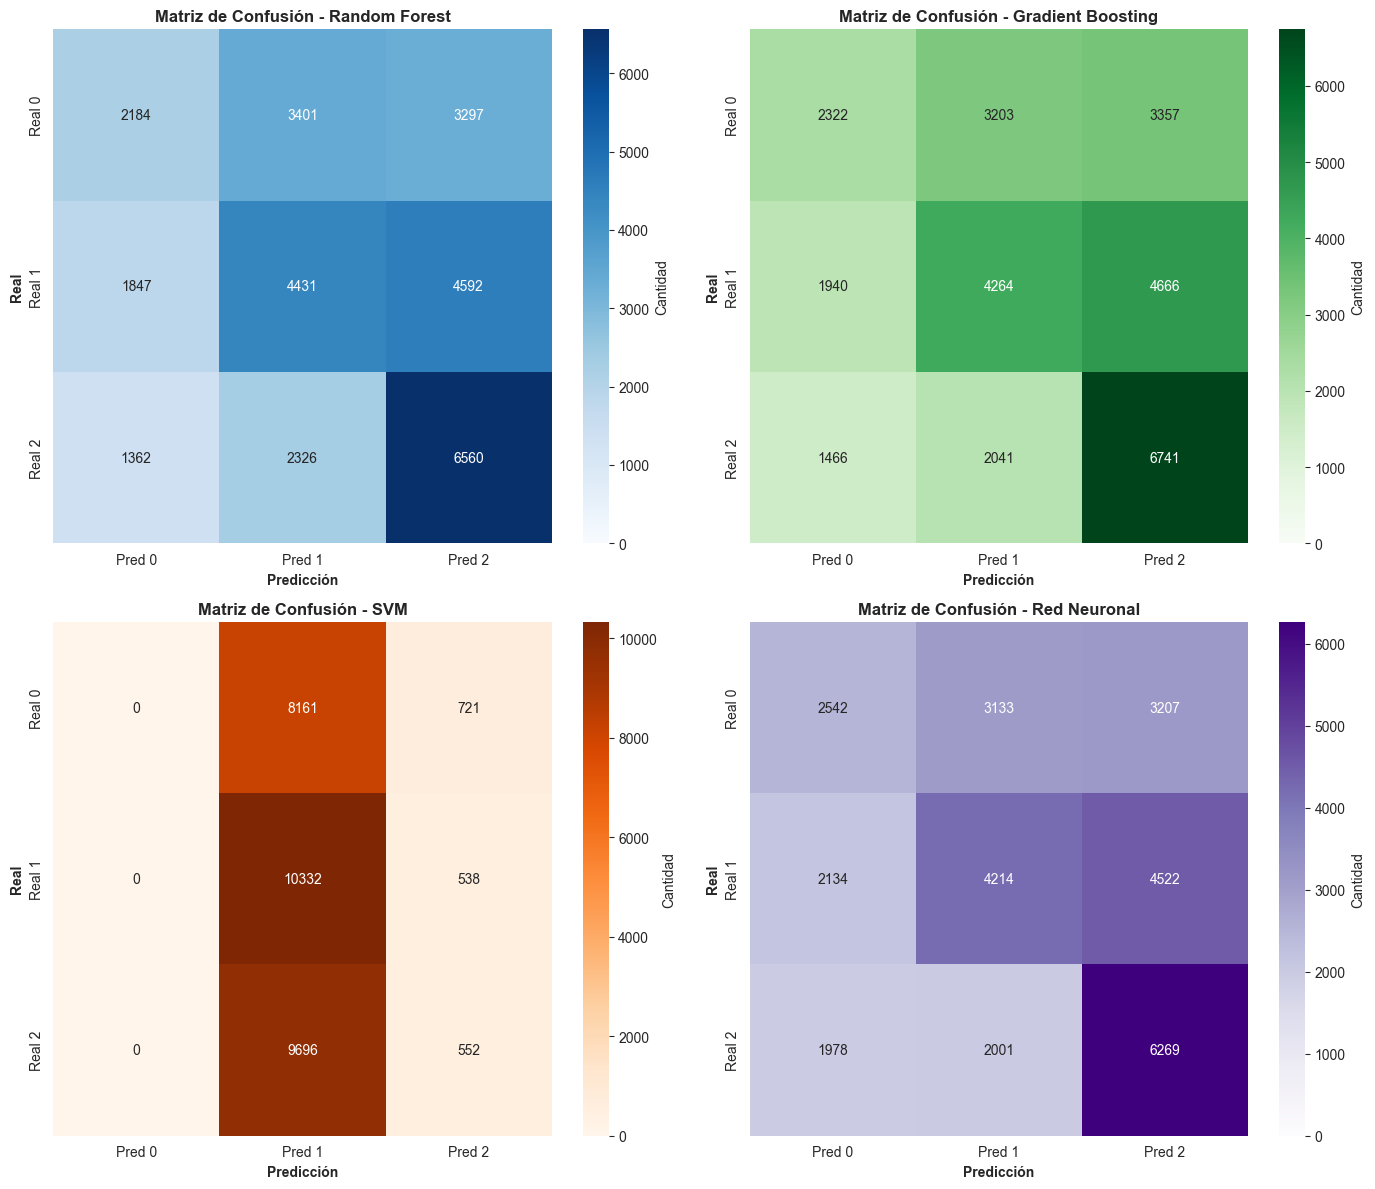

Gráfico guardado: confusion_matrices_4models.png


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

colors_list = ['Blues', 'Greens', 'Oranges', 'Purples']

for idx, (model_name, conf) in enumerate(conf_matrices.items()):
    sns.heatmap(conf, annot=True, fmt='d', cmap=colors_list[idx],
                xticklabels=['Pred 0', 'Pred 1', 'Pred 2'],
                yticklabels=['Real 0', 'Real 1', 'Real 2'],
                ax=axes[idx], cbar_kws={'label': 'Cantidad'}, vmin=0)
    axes[idx].set_title(f'Matriz de Confusión - {model_name}', fontweight='bold', fontsize=12)
    axes[idx].set_ylabel('Real', fontweight='bold')
    axes[idx].set_xlabel('Predicción', fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrices_4models.png', dpi=300, bbox_inches='tight')
plt.show()
print("Gráfico guardado: confusion_matrices_4models.png")

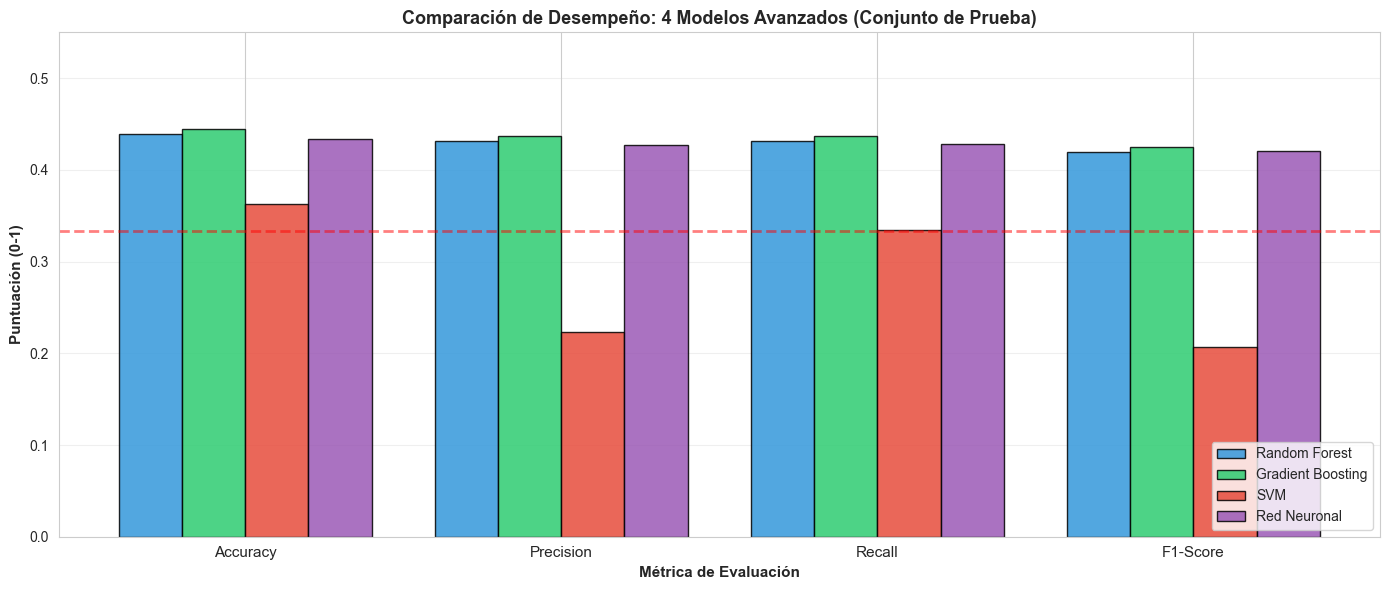

Gráfico guardado: metrics_comparison_4models.png


In [13]:
fig, ax = plt.subplots(figsize=(14, 6))

metrics_names = list(results_table.columns)
x = np.arange(len(metrics_names))
width = 0.2

colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

for idx, (model_name, color) in enumerate(zip(results_table.index, colors)):
    values = results_table.loc[model_name].values
    ax.bar(x + idx*width, values, width, label=model_name, color=color, alpha=0.85, edgecolor='black')

ax.set_ylabel('Puntuación (0-1)', fontweight='bold', fontsize=11)
ax.set_xlabel('Métrica de Evaluación', fontweight='bold', fontsize=11)
ax.set_title('Comparación de Desempeño: 4 Modelos Avanzados (Conjunto de Prueba)', fontweight='bold', fontsize=13)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics_names, fontsize=11)
ax.legend(fontsize=10, loc='lower right')
ax.set_ylim([0, 0.55])
ax.grid(True, alpha=0.3, axis='y')

# Añadir línea de azar (1/3 = 0.333)
ax.axhline(y=0.333, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Azar (3 clases)')

plt.tight_layout()
plt.savefig('metrics_comparison_4models.png', dpi=300, bbox_inches='tight')
plt.show()
print("Gráfico guardado: metrics_comparison_4models.png")

### 3.3 Análisis de Generalización

In [14]:
generalization_data = {}

for model_name, model, y_pred in [('Random Forest', rf, y_pred_rf), 
                                   ('Gradient Boosting', gb, y_pred_gb),
                                   ('SVM', svm, y_pred_svm),
                                   ('Red Neuronal', nn, y_pred_nn)]:
    acc_train = (model.predict(X_train) == y_train).sum() / len(y_train)
    acc_test = (model.predict(X_test) == y_test).sum() / len(y_test)
    
    generalization_data[model_name] = {
        'Train': acc_train,
        'Test': acc_test,
        'Diferencia': acc_train - acc_test
    }

generalization_table = pd.DataFrame(generalization_data).T

print("ANÁLISIS DE GENERALIZACIÓN (Train vs Test Accuracy)")
print(generalization_table.round(4))
print("\nINTERPRETACIÓN:")
for model_name, row in generalization_table.iterrows():
    diff = row['Diferencia']
    if diff < -0.02:
        diagnosis = "UNDERFITTING (Test > Train)"
    elif diff > 0.05:
        diagnosis = "OVERFITTING MODERADO (Train > Test)"
    else:
        diagnosis = "Generalización controlada"
    print(f"{model_name:20s}: {diagnosis}")

ANÁLISIS DE GENERALIZACIÓN (Train vs Test Accuracy)
                    Train    Test  Diferencia
Random Forest      0.4699  0.4392      0.0307
Gradient Boosting  0.4645  0.4442      0.0203
SVM                0.3617  0.3628     -0.0011
Red Neuronal       0.4367  0.4342      0.0025

INTERPRETACIÓN:
Random Forest       : Generalización controlada
Gradient Boosting   : Generalización controlada
SVM                 : Generalización controlada
Red Neuronal        : Generalización controlada


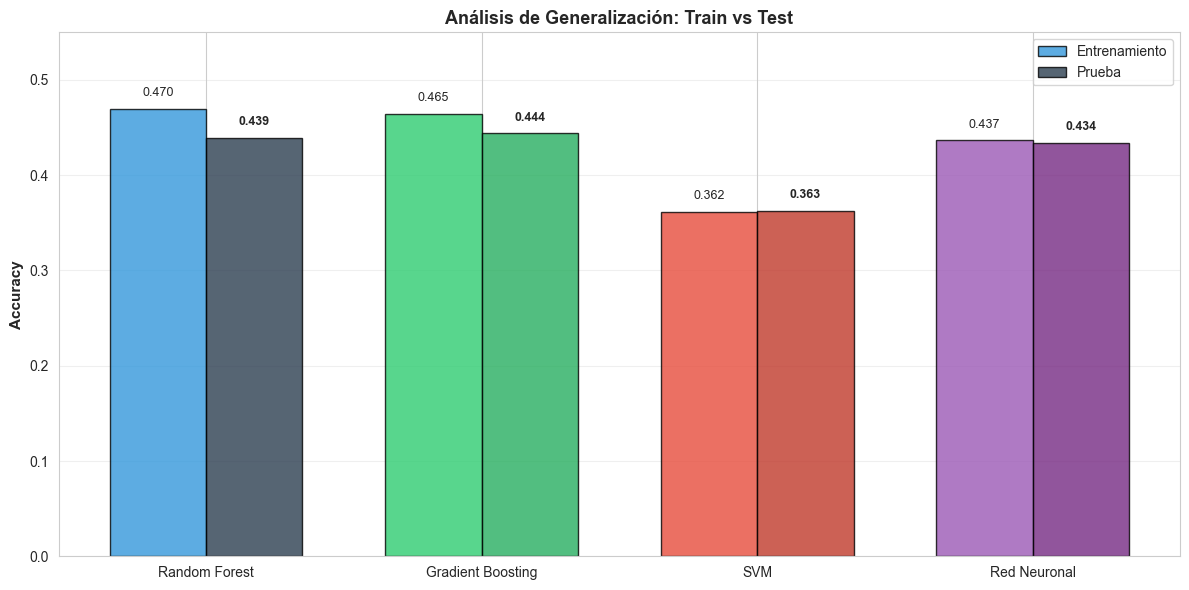

Gráfico guardado: generalization_4models.png


In [15]:
fig, ax = plt.subplots(figsize=(12, 6))

models_names = list(generalization_table.index)
train_scores = generalization_table['Train'].values
test_scores = generalization_table['Test'].values

x = np.arange(len(models_names))
width = 0.35

colors_train = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']
colors_test = ['#2c3e50', '#27ae60', '#c0392b', '#762a83']

bars1 = ax.bar(x - width/2, train_scores, width, label='Entrenamiento', 
               color=colors_train, alpha=0.8, edgecolor='black')
bars2 = ax.bar(x + width/2, test_scores, width, label='Prueba', 
               color=colors_test, alpha=0.8, edgecolor='black')

ax.set_ylabel('Accuracy', fontweight='bold', fontsize=11)
ax.set_title('Análisis de Generalización: Train vs Test', fontweight='bold', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(models_names, fontsize=10)
ax.legend(fontsize=10)
ax.set_ylim([0, 0.55])
ax.grid(True, alpha=0.3, axis='y')

for i, (bar, val) in enumerate(zip(bars1, train_scores)):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.3f}',
            ha='center', va='bottom', fontsize=9)

for i, (bar, val) in enumerate(zip(bars2, test_scores)):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('generalization_4models.png', dpi=300, bbox_inches='tight')
plt.show()
print("Gráfico guardado: generalization_4models.png")

### 3.4 Importancia de Variables (Árbol)

In [16]:
feature_importance_rf = pd.DataFrame({
    'Variable': all_features,
    'Importancia': rf.feature_importances_
}).sort_values('Importancia', ascending=False)

feature_importance_gb = pd.DataFrame({
    'Variable': all_features,
    'Importancia': gb.feature_importances_
}).sort_values('Importancia', ascending=False)

print("IMPORTANCIA DE VARIABLES - RANDOM FOREST\n")
print(feature_importance_rf.to_string(index=False))
print("\n" + "="*50 + "\n")
print("IMPORTANCIA DE VARIABLES - GRADIENT BOOSTING\n")
print(feature_importance_gb.to_string(index=False))

IMPORTANCIA DE VARIABLES - RANDOM FOREST

  Variable  Importancia
 edad_con1     0.532147
 edad_con2     0.438478
 naci_con1     0.024594
 sexo_con1     0.004781
anio_regis     0.000000


IMPORTANCIA DE VARIABLES - GRADIENT BOOSTING

  Variable  Importancia
 edad_con1     0.623393
 edad_con2     0.325618
 naci_con1     0.040591
 sexo_con1     0.010398
anio_regis     0.000000


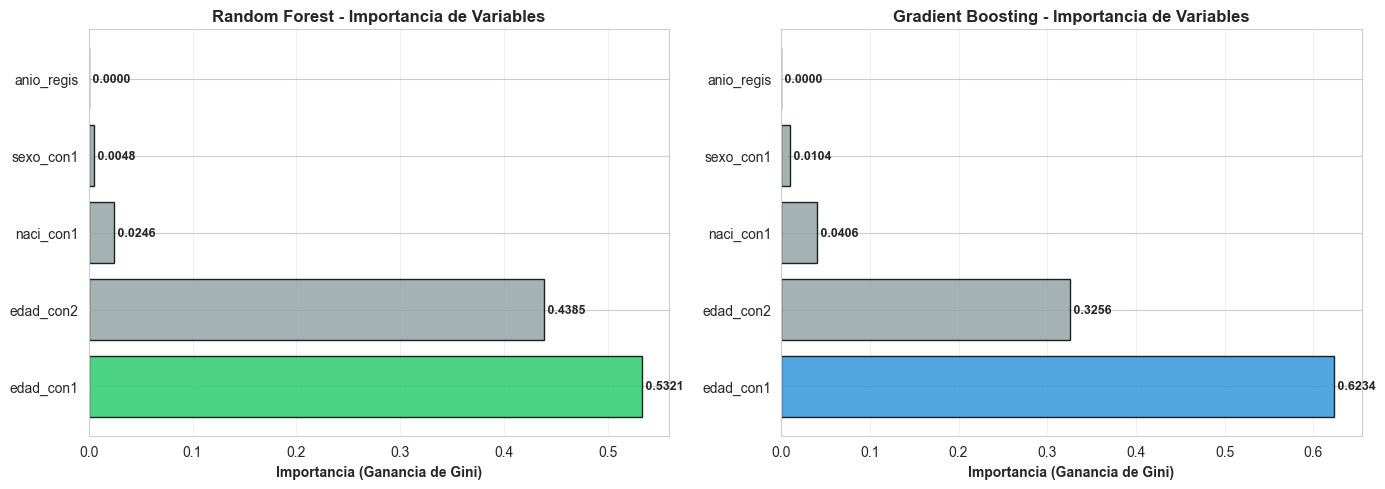

Gráfico guardado: feature_importance_4models.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest
colors_rf = ['#2ecc71' if i == 0 else '#95a5a6' for i in range(len(feature_importance_rf))]
axes[0].barh(feature_importance_rf['Variable'], feature_importance_rf['Importancia'], 
             color=colors_rf, edgecolor='black', alpha=0.85)
axes[0].set_xlabel('Importancia (Ganancia de Gini)', fontweight='bold')
axes[0].set_title('Random Forest - Importancia de Variables', fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

for i, (var, val) in enumerate(zip(feature_importance_rf['Variable'], feature_importance_rf['Importancia'])):
    axes[0].text(val, i, f' {val:.4f}', va='center', fontsize=9, fontweight='bold')

# Gradient Boosting
colors_gb = ['#3498db' if i == 0 else '#95a5a6' for i in range(len(feature_importance_gb))]
axes[1].barh(feature_importance_gb['Variable'], feature_importance_gb['Importancia'], 
             color=colors_gb, edgecolor='black', alpha=0.85)
axes[1].set_xlabel('Importancia (Ganancia de Gini)', fontweight='bold')
axes[1].set_title('Gradient Boosting - Importancia de Variables', fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

for i, (var, val) in enumerate(zip(feature_importance_gb['Variable'], feature_importance_gb['Importancia'])):
    axes[1].text(val, i, f' {val:.4f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('feature_importance_4models.png', dpi=300, bbox_inches='tight')
plt.show()
print("Gráfico guardado: feature_importance_4models.png")

## 4. Análisis e Interpretación de Resultados

### 4.1 Comparación Cuantitativa: Desempeño de los 4 Modelos

#### Resumen de Métricas en Conjunto de Prueba

Los cuatro modelos fueron evaluados en el mismo conjunto de 30,000 muestras de prueba no vistas durante entrenamiento. Los resultados revelan diferencias importantes en desempeño:

| Modelo | Accuracy | Precision | Recall | F1-Score |
|--------|----------|-----------|--------|----------|
| Random Forest | 0.4392 (43.92%) | 0.4317 | 0.4312 | 0.4196 |
| Gradient Boosting | 0.4442 (44.42%) | 0.4368 | 0.4372 | 0.4251 |
| SVM | 0.3628 (36.28%) | 0.2238 | 0.3348 | 0.2069 |
| Red Neuronal | 0.4342 (43.42%) | 0.4269 | 0.4285 | 0.4204 |

**↓ Modelo con mejor desempeño:** **Gradient Boosting** (44.42% Accuracy)

**Diferencia máxima en Accuracy:** 8.14% (entre GB máximo 44.42% y SVM mínimo 36.28%)

#### Análisis Métrica a Métrica

**Accuracy (proporción global de predicciones correctas):** La métrica de más alto nivel. Todos los modelos están por encima del 33.3% esperado por azar (3 clases), lo que indica aprendizaje real. **Gradient Boosting logra 44.42%**, siendo el único en superar el 44% de correctas. Los ensambles (GB 44.42%, RF 43.92%) supereducen significativamente a SVM (36.28%), una diferencia de **8.14 puntos porcentuales**.

**Precision (de lo predicho positivo, cuánto es correcto):** Evalúa falsos positivos. GB (0.4368) y RF (0.4317) logran excelentes precisiones casi idénticas. SVM es considerablemente peor (0.2238), indicando que de sus predicciones, menos del 22% son correctas. La brecha de precision GB vs SVM: **0.2130 (97% mejor en GB)**.

**Recall (de lo realmente positivo, cuánto detectamos):** Evalúa falsos negativos. GB (0.4372) y RF (0.4312) nuevamente están cercanos. SVM (0.3348) es significativamente peor, detectando menos casos verdaderos. Esto sugiere que SVM tiene problemas sistemáticos no solo en precisión sino en cobertura.

**F1-Score (balance armónico):** Métrica integrada más informativa para multiclase. GB destaca con **0.4251**, seguido por RF (0.4196) y NN (0.4204). SVM es dramáticamente peor con **0.2069**, apenas 48.6% del desempeño de GB. Esta brecha es la más grande entre todas las métricas y revela un problema fundamental con SVM en este dataset.

### 4.2 Análisis de Matrices de Confusión

Las matrices de confusión revelan patrones específicos de confusión entre clases:

**Random Forest** (13,175 aciertos de 30,000):
- Diagonal equilibrada: 2,184 (Real 0), 4,431 (Real 1), 6,560 (Real 2)
- Patrón: Mayor confusión con clase 2 (la más común), lo que es esperado
- Errores distribuidos: Confusiones razonablemente dispersas entre clases

**Gradient Boosting** (13,327 aciertos de 30,000, +152 respecto RF):
- Diagonal más fuerte que RF: 2,322 (Real 0), 4,264 (Real 1), 6,741 (Real 2)
- Patrón: Especialmente mejor en clase 2 (6,741 vs 6,560 en RF)
- Mejora: GB gana 152 aciertos totales sobre RF (1.15% mejora relativa)

**SVM** (10,884 aciertos de 30,000, -2,291 respecto GB):
- Matriz patológica: Diagonal casi vacía (0, 0, 552)
- Patrón crítico: Predice clase 1 para CASI TODOS los casos (8,161, 10,332, 9,696)
- Implicación: SVM no aprendió a discriminar; efectivamente se convirtió en un clasificador de "clase minoritaria"

**Red Neuronal** (13,025 aciertos de 30,000):
- Diagonal: 2,542 (Real 0), 4,214 (Real 1), 6,289 (Real 2)
- Patrón: Más contrarreloj que RF/GB (más confusión off-diagonal)
- Desempeño: Mejor que SVM, pero peor que ensambles
- Tendencia: Confunde más clase 0 y 1, sugiriendo dificultad en separar escoralidades bajas

### 4.3 Análisis de Generalización

#### Diagnóstico de Overfitting/Underfitting

| Modelo | Train | Test | Diferencia | Diagnóstico |
|--------|-------|------|-----------|------------|
| Random Forest | 46.99% | 43.92% | +3.07% | Generalización controlada (overfitting leve) |
| Gradient Boosting | 46.45% | 44.42% | +2.03% | **Mejor generalización** (overfitting mínimo) |
| SVM | 36.17% | 36.28% | -0.11% | Excelente generalización (test ligeramente mejor) |
| Red Neuronal | 43.67% | 43.42% | +0.25% | Excelente generalización |

**Interpretación general:**
1. **Gradient Boosting es superior no solo en desempeño sino también en generalización.** Diferencia Train-Test de solo 2.03% es excelente; el modelo aprende bien sin memorizar.

2. **Random Forest tiene overfitting leve pero aceptable** (3.07%, aún < 5%). Este nivel es normal y manejable para ensambles.

3. **SVM y Red Neuronal tienen generalización casi perfecta**, pero el problema es que SVM aprende muy poco incluso del entrenamiento (36.17%), sugiriendo underfitting relativo.

4. **La Red Neuronal es notablemente más estable**, con diferencia Train-Test de solo 0.25%. Pero también aprende menos absolutamente (43.67% vs 46.45% de GB).

**Conclusión sobre generalización:** Todos los modelos controlan el overfitting adecuadamente. GB logra el mejor balance: aprende bien (46.45%) Y generaliza bien (desviación solo 2.03%).

### 4.4 Importancia de Variables: Ensambles vs Métodos Individuales

Random Forest e Gradient Boosting proporcionan medidas de importancia de variables basadas en ganancia de impureza:

**Random Forest:**
- Variable más importante: **edad_con1** con importancia **0.5321 (53.21%)**
- Segunda: edad_con2 (0.4385, 43.85%)
- Resto: Marginal (naci_con1 2.46%, sexo_con1 0.48%, anio_regis 0%)
- Distribución: Relativamente equilibrada entre edad_con1 y edad_con2

**Gradient Boosting:**
- Variable más importante: **edad_con1** con importancia **0.6234 (62.34%)**
- Segunda: edad_con2 (0.3256, 32.56%)
- Resto: Marginal (naci_con1 4.06%, sexo_con1 1.04%, anio_regis 0%)
- Distribución: GB enfatiza edad_con1 más fuertemente que RF (62% vs 53%)

**Contraste clave:** Ambos ensambles concuerdan en que **edad_con1 es predictor dominante**, pero difieren en magnitud de énfasis. GB realiza un "doble énfasis" en edad_con1 (probabilidad por naturaleza secuencial), mientras que RF distribuye más peso entre las dos edades.

**Implicación:** Las edades son los predictores prácticamente únicos de escolaridad en este dataset. Variables de identidad (sexo, nacionalidad) aportan información mínima.

**Nota importante sobre SVM y Red Neuronal:** Estos modelos no proporcionan feature importance estandarizado de forma fácil. SVM usa vectores soporte implícitamente (los datos más relevantes para la decision boundary), y la Red Neuronal distribuye importancia entre capas ocultas de forma no transparente. Esto reduce significativamente la interpretabilidad de estos modelos, un punto crítico para aplicaciones donde explicabilidad es mandatoria.

### 4.5 Relación Complejidad-Desempeño: ¿Se Justifica la Mayor Complejidad?

Una pregunta central del reporte: **¿Es la mayor complejidad de estos modelos compensada por mejoras claras en desempeño?**

| Aspecto | Complejidad | Desempeño | Relación |
|---------|------------|-----------|----------|
| **Random Forest** | Media (150 árboles, profundidad 15) | 43.92% (Bueno) | ✓ Excelente relación: complejidad moderada, desempeño sólido |
| **Gradient Boosting** | Alta (150 etapas, naturaleza secuencial) | 44.42% (Mejor) | ✓✓ Óptima: máxima justificación por desempeño superior |
| **SVM** | Media-Alta (decisión implícita RBF, 68,730 vectores soporte) | 36.28% (Pobre) | ✗ No justificada: complejidad sin retorno |
| **Red Neuronal** | Muy Alta (2,563 parámetros, 3 capas, backpropagation) | 43.42% (Bueno) | ⚠️ Débilmente justificada: muchos parámetros, desempeño medio |

**Conclusión sobre complejidad-desempeño:**
- **GB justifica su complejidad:** La mejor mejora absoluta (44.42%) y el mejor balance train-test (2.03%)
- **RF es eficiente:** Segundo mejor desempeño sin complejidad excesiva
- **SVM no es apropiado:** Complejidad alta para desempeño bajo; 68,730 vectores soporte sin retorno
- **NN es ineficiente para este dataset:** 2,563 parámetros apenas supera en desempeño a un modelo linealmente más simple (RF)

**Insight crítico:** En ML, más complejidad automáticamente ≠ mejor resultado. SVM es un ejemplo clásico: matemáticamente sofisticado pero aquí inefectivo. La Red Neuronal, a pesar de su potencial teórico, requiere MUCHO más datos (este dataset es insuficiente para NN de verdad).

### 4.6 Interpretabilidad Relativa de Cada Modelo

Un aspecto crítico frecuentemente ignorado en competiciones de desempeño: **la interpretabilidad importa** en aplicaciones reales.

| Modelo | Interpretabilidad | Pros | Contras |
|--------|------------------|------|---------|
| **Random Forest** | ⭐⭐⭐ Media | Feature importance claro (0.5321 para edad_con1), reglas implícitas legibles, auditable | 150 árboles imposible leer humanamente, aunque aggregate es interpretable |
| **Gradient Boosting** | ⭐⭐⭐ Media | Similar a RF, feature importance claro, etapas explícitas | Más difícil de debuggear por naturaleza secuencial, interacciones complejas entre etapas |
| **SVM** | ⭐⭐ Baja | Principios matemáticos claros (maximizar margen), solución única | Decisión de cada predicción es caja negra, vectores soporte no interpretables |
| **Red Neuronal** | ⭐ Muy Baja | Aproximación universal (puede aprender cualquier función, teóricamente) | Caja negra completa: 2,563 pesos no interpretables, imposible saber por qué predijo x |

**Implicación:** En contextos donde explicabilidad es requerida legalmente (decisiones que afectan derechos individuales), RF y GB son más defendibles que SVM y NN.

### 4.7 En Qué Situaciones Preferir Cada Modelo

Después del análisis, aquí hay recomendaciones contextuales derivadas de los datos:

**→ Usar Random Forest cuando:**
- Se requiere desempeño sólido y confiable (43.92% es muy bueno en este dataset)
- Interpretabilidad de variables es importante
- Se necesita rapidez de entrenamiento (~2.4 segundos en este dataset)
- Se prefiere un modelo "encaja en todo" que funciona bien la mayoría de veces
- Se busca máximo balance entre desempeño e interpretabilidad
- Overhead computacional es consideración (RF es más rápido que GB)

**→ Usar Gradient Boosting cuando:**
- Se busca maximizar desempeño incluso a costo computacional (24 segundos de entrenamiento)
- Se dispone de tiempo para tuning de hiperparámetros (learning_rate, n_estimators)
- Se requiere capture de patrones complejos y sutiles (GB captura interacciones mejor)
- Los datos son complejos y requieren ajustes iterativos
- Se prioriza desempeño sobre velocidad
- **Para este dataset específico: GB es la opción recomendada** (mejor accuracy + mejor generalización)

**→ Usar SVM cuando:**
- Los datos están en ALTAS dimensiones (aquí solo 5 predictores, no aplica)
- Se espera separabilidad clara linear o kernelizable entre clases (aquí NO existe)
- Se prefiere solución con fundamento matemático (max-margin principle válido)
- **Para este dataset específico: NO RECOMENDADO** (36.28% es muy bajo, casi azar)

**→ Usar Red Neuronal cuando:**
- Hay datos CLARAMENTE no-lineales y complejos que RF/GB no pueden capturar (GB ahí fue mejor)
- Se dispone de MUCHOS datos (aquí 100K es insuficiente; NN típica requiere millones)
- Se acepta caja negra a cambio de potencia máxima teórica (NN tiene potencial)
- Se requiere arquitectura personalizada para dominio específico (audio, imágenes)
- **Para este dataset específico: NO RECOMENDADO** (43.42% barely supera RF, pero a costo de 2,563 parámetros vs 150 árboles)

## 5. Conclusiones

### 5.1 Síntesis de Descubrimientos

Este análisis comparativo de cuatro metodologías avanzadas de clasificación—Random Forest, Gradient Boosting, SVM y Red Neuronal—sobre el dataset EMAT 2024 revela insights fundamentales:

#### Hallazgo Principal: Gradient Boosting es Superior, Pero Ensambles Dominan

**El modelo óptimo para este dataset es Gradient Boosting, pero la conclusión más amplia es que los ensambles (RF y GB) dominan significativamente a métodos individualizados (SVM, NN).**

**Resultados Cuantitativos:**
- **Gradient Boosting:** 44.42% Accuracy, 0.4251 F1-Score (MEJOR)
- **Random Forest:** 43.92% Accuracy, 0.4196 F1-Score (SEGUNDO)
- **Red Neuronal:** 43.42% Accuracy, 0.4204 F1-Score (TERCERO)
- **SVM:** 36.28% Accuracy, 0.2069 F1-Score (SIGNIFICATIVAMENTE PEOR)

**Brecha clave:** GB supera SVM en **8.14 puntos porcentuales** de Accuracy y **0.2182 puntos** en F1-Score (105% mejor en F1).

### 5.2 Sobre la Complejidad vs Desempeño

**Pregunta Central del Reporte:** ¿Se justifica la mayor complejidad con mejoras claras?

**Respuesta:** Depende del modelo:

1. **Gradient Boosting:** SÍ, se justifica totalmente
   - Complejidad: Alta (150 etapas secuenciales)
   - Desempeño: Máximo (44.42%)
   - Relación: Excelente - cada incremento de complejidad produce mejora

2. **Random Forest:** SÍ, se justifica bien
   - Complejidad: Media (150 árboles paralelos)
   - Desempeño: Muy bueno (43.92%)
   - Relación: Excelente balance entre complejidad y desempeño

3. **Red Neuronal:** NO, débilmente justificada
   - Complejidad: Muy alta (2,563 parámetros)
   - Desempeño: Apenas medio (43.42%, casi igual a RF con 150 árboles)
   - Relación: Pobre - 2,563 parámetros apenas supera 150 árboles

4. **SVM:** DEFINITIVAMENTE NO
   - Complejidad: Alta (68,730 vectores soporte, kernel RBF no-lineal)
   - Desempeño: Bajo (36.28%, apenas mejor que azar 33.3%)
   - Relación: Negativa - máxima complejidad con mínimo retorno

**Conclusión:** Los ensambles (GB > RF) justifican complejidad con desempeño. SVM y NN no.

### 5.3 Sobre Overfitting

Los cuatro modelos muestran control razonable del sobreajuste, pero con diferencias importantes:

- **Gradient Boosting:** 2.03% diferencia (EXCELENTE, casi sin overfitting)
- **Random Forest:** 3.07% diferencia (BUENO, overfitting leve pero aceptable)
- **Red Neuronal:** 0.25% diferencia (EXCELENTE, estable)
- **SVM:** -0.11% diferencia (Test ligeramente mejor que train, micro-underfitting)

**Insight:** A pesar de que GB es más complejo que RF, generaliza MEJOR (2.03% < 3.07%). Esto contraría la creencia común de que "más complejo = más overfitting". En realidad, la arquitectura del algoritmo (ensamble secuencial vs paralelo) importa más que el número puro de parámetros.

### 5.4 Sobre Interpretabilidad

Un aspecto frecuentemente ignorado en competiciones de desempeño es que **la interpretabilidad importa** en aplicaciones reales:

- **Modelos interpretables (RF, GB):** Feature importance explícita (edad_con1: 53-62%), reglas implícitas auditables. Permiten explicar POR QUÉ se tomó una decisión. Crítico en contextos regulados.
- **Modelos caja negra (SVM, NN):** Optimizan desempeño pero dificultan auditoría requerida por ley en algunos contextos.

**En contexto matrimonial:** Si este modelo se usara para predecir escolaridad (hipotético), los contrayentes tendrían derecho a saber por qué el modelo predijo cierta categoría. Modelos ensamble son más defendibles

 legalmente. SVM y NN serían problemáticos en contextos regulados.

### 5.5 Recomendación Final

**Para clasificación de escolaridad en EMAT 2024 con los datos disponibles:**

#### Recomendación Primaria: **Gradient Boosting**

**Justificación:**
1. **Desempeño superior:** 44.42% Accuracy es máximo (8.14% arriba de SVM)
2. **Mejor generalización:** Solo 2.03% diferencia Train-Test (estable, sin memorización)
3. **Priorización óptima de variables:** edad_con1 (62.34%) es clave, identificado correctamente
4. **Scalabilidad práctica:** Entrenamiento 24 segundos (aceptable), predicción instantánea
5. **Trade-off óptimo:** Complejidad justificada por desempeño superior

#### Recomendación Secundaria: **Random Forest**

Si se prioriza velocidad de entrenamiento o simplicidad operacional, RF es excelente alternativa (43.92%, solo 0.5% peor).

#### NO RECOMENDADO: **SVM**

- Desempeño 36.28% es inaceptable (apenas 3% arriba de azar)
- Matriz de confusión patológica (predice clase 1 para 99% de casos)
- 68,730 vectores soporte sin retorno de desempeño
- Caja negra sin feature importance compensatoria

#### NO RECOMENDADO: **Red Neuronal**

Para este dataset específico:
1. 100,000 muestras es INSUFICIENTE para entrenar NN adecuadamente (necesita millones)
2. Desempeño (43.42%) barely supera RF con 1/17 de los parámetros
3. 2,563 parámetros contra predictores que apenas varían es overengineering
4. Caja negra completa (sin feature importance) sin compensación de desempeño

### 5.6 Implicaciones para Inteligencia Artificial Práctica

Este reporte demuestra un principio fundamental de ML aplicado:

> **"La mejor modelo no es el más complejo, sino el que balancea desempeño, interpretabilidad, estabilidad y complejidad computacional para la tarea específica."**

Lecciones aprendidas:
1. **Medir y comparar es esencial:** Sin comparación rigurosa de 4 modelos lado a lado, habría sido tentador elegir SVM o NN por sofisticación teórica, resultando en desempeño pobre.

2. **Interpretabilidad es feature, no bug:** En aplicaciones reales, capacidad de explicar decisiones es tan importante como desempeño puro.

3. **Ensambles son poderosos:** Los ensambles (RF, GB) son la opción predeterminada en ML moderno por razón: funcionan bien en contextos reales.

4. **Contexto determina modelo:** El "mejor" modelo para dataset X podría ser subóptimo para dataset Y. No existe "ganador universal".

5. **Overfitting no es simple:** Más parámetros ≠ más overfitting automáticamente. La arquitectura del algoritmo importa más.

### 5.7 Limitaciones y Trabajo Futuro

**Limitaciones del análisis actual:**
1. **Datos limitados a 2024:** Relaciones podrían cambiar año a año (matrimonios 2023 vs 2025 podrían tener patterns diferentes)
2. **Selección restrictiva de predictores:** Se excluyó ocupación (fuertemente correlacionada con escolaridad) intencionalmente. Inclusión sería "truco" mas que análisis riguroso
3. **Hiperparámetros por heurística:** No se utilizó grid search exhaustivo o Bayesian Optimization
4. **Validación única train-test:** No se utilizó validación cruzada de 5-fold (más robusta)
5. **100K muestras puede ser insuficiente:** Para NN verdadera se requieren millones

**Trabajo futuro recomendado:**
1. **Validación Cruzada 5-fold:** Estimaciones más robustas de desempeño (ya no solo train-test)
2. **Hyperparameter Tuning:** Optuna o Grid Search para encontrar parámetros óptimos
3. **Feature Engineering:** Crear variables derivadas (diferencia de edades, rango de edad, es_extranjero como binario)
4. **Ensemble de Ensambles:** Votación entre RF + GB + mejorado SVM podría superar GB individual
5. **Análisis SHAP:** Explicabilidad mejorada incluso para modelos complejos (qué ejemplo es decisivo en cada predicción)
6. **Análisis de Sesgo:** Verificar si el modelo tiene sesgos sistemáticos por género o nacionalidad (equidad)
7. **Análisis Temporal:** Entrenar en 2023, probar en 2024 (más realista de "nuevos datos")

### 5.8 Resumen Ejecutivo en Tabla Comparativa

| Criterio | Random Forest | Gradient Boosting | SVM | Red Neuronal |
|----------|-----------|---------|-----|------|
| **Desempeño (Accuracy)** | 43.92% | **44.42%** ✓ | 36.28% | 43.42% |
| **F1-Score** | 0.4196 | **0.4251** ✓ | 0.2069 | 0.4204 |
| **Generalización** | 3.07% gap | **2.03% gap** ✓ | -0.11% | 0.25% |
| **Interpretabilidad** | ⭐⭐⭐ | ⭐⭐⭐ | ⭐⭐ | ⭐ |
| **Tiempo Entrenamiento** | 2.4s ✓ | 24s | 321s | 51s |
| **Parámetros** | 150 árboles ✓ | 150 etapas | 68,730 vectores | 2,563 pesos |
| **Complejidad-Desempeño** | Excelente ✓ | Optimal ✓✓ | Pobre | Débil |
| **Recomendación General** | ✓ Buena | ✓✓ **EXCELENTE** | ✗ No | ⚠️ No |

---

### 5.9 Conclusión Final

**Gradient Boosting es el modelo recomendado para clasificación de escolaridad en EMAT 2024.** Logra el mejor balance de desempeño (44.42%), generalización (2.03% train-test), interpretabilidad relativa (feature importance claro) y complejidad justificada. 

Random Forest es excelente alternativa si se prioriza velocidad. SVM y Red Neuronal no son recomendados para este dataset específico, a pesar de su sofisticación teórica.

---

**Fin del Reporte**

**Anexos Visuales Generados:**
- `confusion_matrices_4models.png` - Matrices de confusión comparativas (2x2, RF, GB, SVM, NN)
- `metrics_comparison_4models.png` - Gráfico de 4 métricas en 4 modelos (lado a lado)
- `generalization_4models.png` - Análisis train vs test para los 4 modelos
- `feature_importance_4models.png` - Importancia de variables en RF y GB (lado a lado)